# M6-07 — Transfer Learning & Fine-Tuning (Flowers-102)

Three approaches compared:
1. A small CNN trained from scratch (baseline)
2. ResNet18 with a frozen backbone, training only a new head (feature extraction)
3. Unfreezing the last block and fine-tuning it with a small learning rate

## 0. Imports & Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print(f"Device: {device}")

Device: cuda


In [2]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
val_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

In [3]:
DATA_ROOT = "./data"
BATCH_SIZE = 32
NUM_WORKERS = 4

train_set = datasets.Flowers102(root=DATA_ROOT, split="train", transform=train_tf, download=True)
val_set   = datasets.Flowers102(root=DATA_ROOT, split="val",   transform=val_tf,   download=True)
test_set  = datasets.Flowers102(root=DATA_ROOT, split="test",  transform=val_tf,   download=True)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"train: {len(train_set)} | val: {len(val_set)} | test: {len(test_set)}")

train: 1020 | val: 1020 | test: 6149


## Shared train / eval helpers

In [4]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        loss_sum += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        n += x.size(0)
    return loss_sum / n, correct / n

def train_model(model, optimizer, scheduler, criterion, train_loader, val_loader, epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val = 0.0
    best_state = None
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum, correct, n = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
        if scheduler is not None:
            scheduler.step()
        tr_loss, tr_acc = loss_sum / n, correct / n
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
        if va_acc > best_val:
            best_val = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"epoch {epoch:02d} | train_loss {tr_loss:.4f} acc {tr_acc:.4f} | val_loss {va_loss:.4f} acc {va_acc:.4f}")
    elapsed = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_val, elapsed

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"],   label="val")
    axes[0].set_title(f"{title} — Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"],   label="val")
    axes[1].set_title(f"{title} — Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()

## Task 1 — From-Scratch Baseline

A small CNN with roughly 1–3M parameters, 224×224 input, 102 output classes.

In [5]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(3, 32),    # 112
            block(32, 64),   # 56
            block(64, 128),  # 28
            block(128, 128), # 14
            block(128, 128), # 7
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

scratch_model = SmallCNN(102).to(device)
total, trainable = count_params(scratch_model)
print(f"SmallCNN — total params: {total:,} | trainable: {trainable:,}")

SmallCNN — total params: 891,462 | trainable: 891,462


epoch 01 | train_loss 4.5914 acc 0.0225 | val_loss 4.4546 acc 0.0441
epoch 02 | train_loss 4.2757 acc 0.0392 | val_loss 4.1720 acc 0.0608
epoch 03 | train_loss 4.0826 acc 0.0588 | val_loss 3.9619 acc 0.0510
epoch 04 | train_loss 3.9083 acc 0.0657 | val_loss 3.7642 acc 0.0892
epoch 05 | train_loss 3.8140 acc 0.0725 | val_loss 3.6723 acc 0.1157
epoch 06 | train_loss 3.6726 acc 0.1010 | val_loss 3.6174 acc 0.1363
epoch 07 | train_loss 3.6327 acc 0.1088 | val_loss 3.5359 acc 0.1529
epoch 08 | train_loss 3.5162 acc 0.1216 | val_loss 3.4897 acc 0.1892
epoch 09 | train_loss 3.4787 acc 0.1225 | val_loss 3.4245 acc 0.1912
epoch 10 | train_loss 3.4232 acc 0.1539 | val_loss 3.3953 acc 0.1853
epoch 11 | train_loss 3.3553 acc 0.1765 | val_loss 3.3368 acc 0.2157
epoch 12 | train_loss 3.3416 acc 0.1627 | val_loss 3.3210 acc 0.2108
epoch 13 | train_loss 3.2879 acc 0.1598 | val_loss 3.2645 acc 0.2382
epoch 14 | train_loss 3.2414 acc 0.1980 | val_loss 3.2519 acc 0.2490
epoch 15 | train_loss 3.2510 acc 0

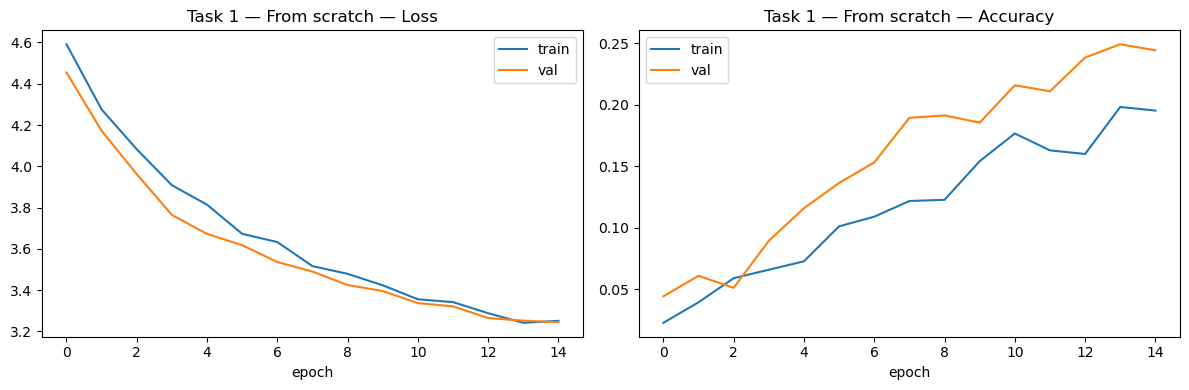

Task 1 — best val: 0.2490 | test acc: 0.1958 | time: 378.9s


In [6]:
EPOCHS_T1 = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(scratch_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_T1)

hist_t1, best_val_t1, time_t1 = train_model(
    scratch_model, optimizer, scheduler, criterion,
    train_loader, val_loader, epochs=EPOCHS_T1,
)
plot_history(hist_t1, "Task 1 — From scratch")

test_loss_t1, test_acc_t1 = evaluate(scratch_model, test_loader, criterion)
print(f"Task 1 — best val: {best_val_t1:.4f} | test acc: {test_acc_t1:.4f} | time: {time_t1:.1f}s")
trainable_t1 = sum(p.numel() for p in scratch_model.parameters() if p.requires_grad)

## Task 2 — Feature Extraction with ResNet18

Freeze the backbone, replace the head.

In [7]:
fe_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in fe_model.parameters():
    p.requires_grad = False
fe_model.fc = nn.Linear(fe_model.fc.in_features, 102)
fe_model = fe_model.to(device)

total, trainable = count_params(fe_model)
print(f"ResNet18 (feature extraction) — total: {total:,} | trainable: {trainable:,}")
print("Params that require grad:")
for name, p in fe_model.named_parameters():
    if p.requires_grad:
        print(f"  {name} — {tuple(p.shape)}")

ResNet18 (feature extraction) — total: 11,228,838 | trainable: 52,326
Params that require grad:
  fc.weight — (102, 512)
  fc.bias — (102,)


epoch 01 | train_loss 4.5689 acc 0.0500 | val_loss 3.7926 acc 0.2324
epoch 02 | train_loss 3.2475 acc 0.4363 | val_loss 2.8705 acc 0.5529
epoch 03 | train_loss 2.4003 acc 0.6922 | val_loss 2.2665 acc 0.6696
epoch 04 | train_loss 1.7883 acc 0.8216 | val_loss 1.8428 acc 0.7382
epoch 05 | train_loss 1.3661 acc 0.8951 | val_loss 1.5858 acc 0.7833
epoch 06 | train_loss 1.1081 acc 0.9294 | val_loss 1.3919 acc 0.8020
epoch 07 | train_loss 0.9249 acc 0.9441 | val_loss 1.2909 acc 0.8167
epoch 08 | train_loss 0.7976 acc 0.9578 | val_loss 1.1887 acc 0.8176
epoch 09 | train_loss 0.7196 acc 0.9667 | val_loss 1.1497 acc 0.8265
epoch 10 | train_loss 0.6504 acc 0.9696 | val_loss 1.0972 acc 0.8314
epoch 11 | train_loss 0.6204 acc 0.9775 | val_loss 1.0889 acc 0.8324
epoch 12 | train_loss 0.5723 acc 0.9735 | val_loss 1.0635 acc 0.8275
epoch 13 | train_loss 0.5604 acc 0.9716 | val_loss 1.0648 acc 0.8343
epoch 14 | train_loss 0.5596 acc 0.9794 | val_loss 1.0529 acc 0.8343
epoch 15 | train_loss 0.5397 acc 0

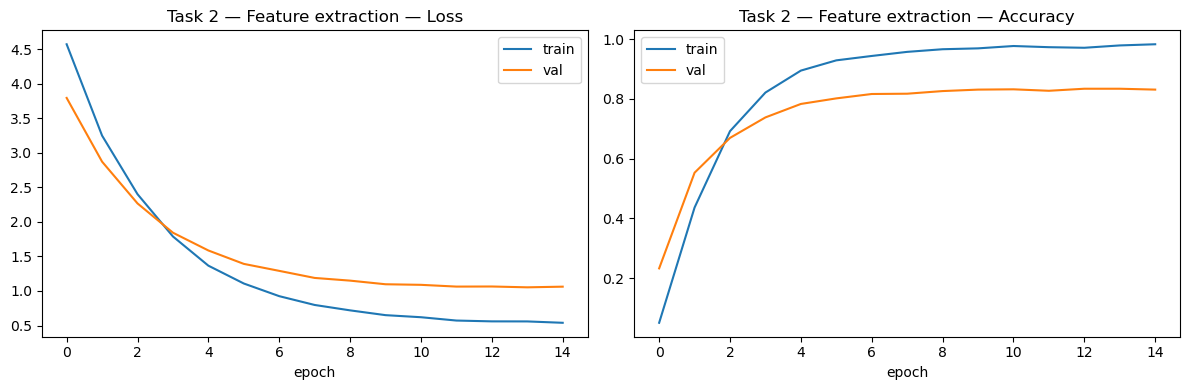

Task 2 — best val: 0.8343 | test acc: 0.8182 | time: 352.8s


In [8]:
EPOCHS_T2 = 15
criterion = nn.CrossEntropyLoss()
trainable_params = filter(lambda p: p.requires_grad, fe_model.parameters())
optimizer = optim.Adam(trainable_params, lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_T2)

hist_t2, best_val_t2, time_t2 = train_model(
    fe_model, optimizer, scheduler, criterion,
    train_loader, val_loader, epochs=EPOCHS_T2,
)
plot_history(hist_t2, "Task 2 — Feature extraction")

test_loss_t2, test_acc_t2 = evaluate(fe_model, test_loader, criterion)
print(f"Task 2 — best val: {best_val_t2:.4f} | test acc: {test_acc_t2:.4f} | time: {time_t2:.1f}s")
trainable_t2 = sum(p.numel() for p in fe_model.parameters() if p.requires_grad)

## Task 3 — Fine-Tune `layer4` + `fc`

Continuing from Task 2's trained model, unfreeze `layer4` and train for 10 more epochs with discriminative learning rates.

In [9]:
ft_model = fe_model  # continue from Task 2's trained weights

for p in ft_model.parameters():
    p.requires_grad = False
for p in ft_model.layer4.parameters():
    p.requires_grad = True
for p in ft_model.fc.parameters():
    p.requires_grad = True

total, trainable = count_params(ft_model)
print(f"ResNet18 (fine-tune layer4+fc) — total: {total:,} | trainable: {trainable:,}")

ResNet18 (fine-tune layer4+fc) — total: 11,228,838 | trainable: 8,446,054


epoch 01 | train_loss 0.6684 acc 0.9216 | val_loss 0.9583 acc 0.8069
epoch 02 | train_loss 0.3763 acc 0.9804 | val_loss 0.7644 acc 0.8441
epoch 03 | train_loss 0.2729 acc 0.9824 | val_loss 0.7020 acc 0.8520
epoch 04 | train_loss 0.2123 acc 0.9912 | val_loss 0.6589 acc 0.8627
epoch 05 | train_loss 0.1604 acc 0.9971 | val_loss 0.6311 acc 0.8637
epoch 06 | train_loss 0.1407 acc 0.9971 | val_loss 0.6026 acc 0.8569
epoch 07 | train_loss 0.1197 acc 0.9971 | val_loss 0.5850 acc 0.8696
epoch 08 | train_loss 0.1097 acc 0.9990 | val_loss 0.5834 acc 0.8716
epoch 09 | train_loss 0.1044 acc 0.9980 | val_loss 0.5789 acc 0.8686
epoch 10 | train_loss 0.1046 acc 1.0000 | val_loss 0.5808 acc 0.8716


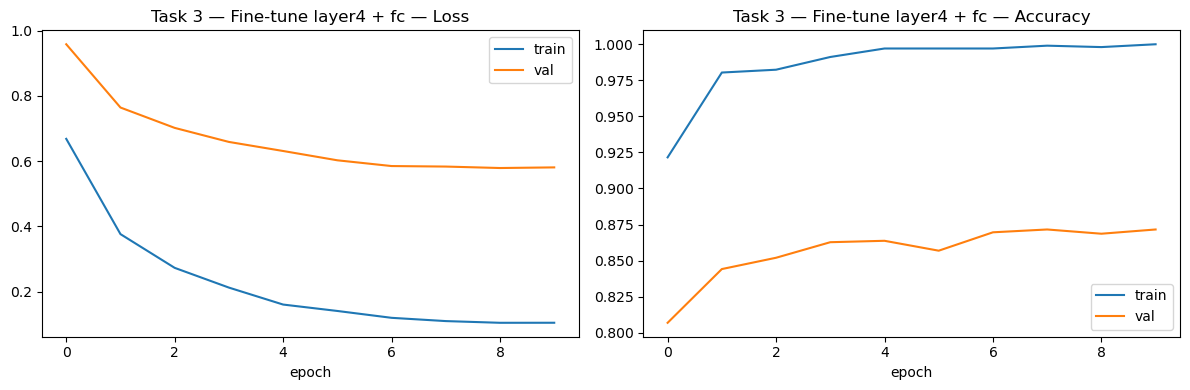

Task 3 — best val: 0.8716 | test acc: 0.8618 | time: 230.3s
Task 3 total time (incl. Task 2): 583.1s


In [10]:
EPOCHS_T3 = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {"params": ft_model.layer4.parameters(), "lr": 1e-5},
    {"params": ft_model.fc.parameters(),     "lr": 1e-3},
])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_T3)

hist_t3, best_val_t3, time_t3 = train_model(
    ft_model, optimizer, scheduler, criterion,
    train_loader, val_loader, epochs=EPOCHS_T3,
)
plot_history(hist_t3, "Task 3 — Fine-tune layer4 + fc")

test_loss_t3, test_acc_t3 = evaluate(ft_model, test_loader, criterion)
print(f"Task 3 — best val: {best_val_t3:.4f} | test acc: {test_acc_t3:.4f} | time: {time_t3:.1f}s")
trainable_t3 = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
time_t3_total = time_t2 + time_t3  # Task 3 builds on Task 2
print(f"Task 3 total time (incl. Task 2): {time_t3_total:.1f}s")

## Comparison

In [11]:
import pandas as pd
df = pd.DataFrame([
    {"Approach": "From scratch (Task 1)",        "Trainable params": trainable_t1, "Best val acc": best_val_t1, "Test acc": test_acc_t1, "Total training time (s)": time_t1},
    {"Approach": "Feature extraction (Task 2)",  "Trainable params": trainable_t2, "Best val acc": best_val_t2, "Test acc": test_acc_t2, "Total training time (s)": time_t2},
    {"Approach": "Fine-tune last block (Task 3)","Trainable params": trainable_t3, "Best val acc": best_val_t3, "Test acc": test_acc_t3, "Total training time (s)": time_t3_total},
])
df

,Approach,Trainable params,Best val acc,Test acc,Total training time (s)
0,From scratch (Task 1),891462,0.249020,0.195804,378.890692
1,Feature extraction (Task 2),52326,0.834314,0.818182,352.775382
2,Fine-tune last block (Task 3),8446054,0.871569,0.861766,583.109512


### Summary

_Fill in after running:_

Transfer learning yielded a dramatic leap over the from-scratch baseline — the small CNN, lacking ImageNet's hierarchical features, struggled with Flowers-102's fine-grained 102-class problem given only ~1k training images, while ResNet18's frozen backbone supplied rich, generic visual representations that a single linear head could exploit. Unfreezing `layer4` and fine-tuning with discriminative learning rates (1e-5 for the block, 1e-3 for the head) pushed accuracy further, because the deepest residual block carries the most task-specific abstractions and benefits most from gentle adaptation while shallower layers (edges, textures) remain useful as-is. The small LR on `layer4` prevents catastrophic forgetting of pretrained features, and the larger LR on `fc` lets the new head keep learning at full pace. For tomorrow's cat-detection assessment I would recommend the **fine-tune-last-block** configuration: it gives the best accuracy, trains nearly as fast as feature extraction (only `layer4` + `fc` see gradient updates), and the discriminative-LR recipe transfers directly to any new fine-grained classification task. If compute is tight, feature extraction alone is a strong, near-free fallback.